In [307]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy import *

# Question 6

In this problem, you are going to use trajectory optimization to find obstacle-free paths
for a robot.
You will start with an obstacle cost world and a straight line path that blasts through the obstacles, as in Figure 1 and 2.
We are providing some starter code to make it easier - see the files trajectory\_optimization.{m|py}.
For your code, you mainly just need to add the actual optimization code to one of these files.

In [308]:
def generate_cost():
    n = 101
    obstacles = np.array([[20, 30], [60, 40], [70, 85]])
    epsilon = np.array([[25], [20], [30]])
    obstacle_cost = np.zeros((n, n))
    for i in range(obstacles.shape[0]):
        t = np.ones((n, n))
        t[obstacles[i, 0], obstacles[i, 1]] = 0
        t_cost = ndimage.distance_transform_edt(t)
        t_cost[t_cost > epsilon[i]] = epsilon[i]
        t_cost = (1 / (2 * epsilon[i])) * (t_cost - epsilon[i]) ** 2
        obstacle_cost += +t_cost
    return obstacle_cost

In [309]:
def plot_scene(path, cost, title=None, save_prefix=None, elev=45, azim=90):
    values = get_values(path, cost)

    # Plot 2D
    plt.imshow(cost.T)
    if title is not None:
        plt.title(title + " 2D")
    plt.plot(path[:, 0], path[:, 1], "ro")
    if save_prefix is not None:
        plt.savefig(save_prefix + "_2D.png")

    # Plot 3D
    fig3d = plt.figure()
    ax3d = fig3d.add_subplot(111, projection="3d")
    ax3d.view_init(elev=elev, azim=azim)
    xx, yy = np.meshgrid(range(cost.shape[1]), range(cost.shape[0]))
    ax3d.plot_surface(xx, yy, cost.T, cmap=plt.get_cmap("coolwarm"), alpha=0.5)
    ax3d.scatter(path[:, 0], path[:, 1], values, s=20, c="r")
    if title is not None:
        plt.title(title + " 3D")
    if save_prefix is not None:
        plt.savefig(save_prefix + "_3D.png")
    plt.show()

In [310]:
cost_map = generate_cost()

In [311]:
start_point = np.array([10, 10])
end_point = np.array([90, 90])
vector = end_point - start_point

num_pts = 300
initial_path = start_point + np.outer(np.linspace(0, 1, num_pts), vector)

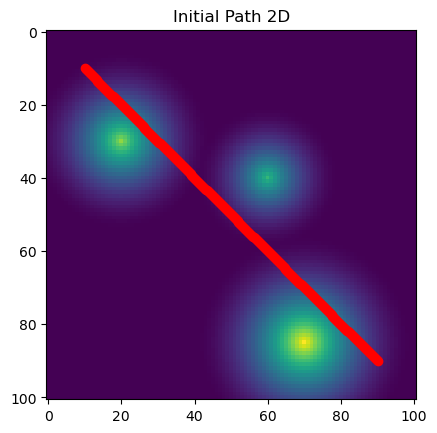

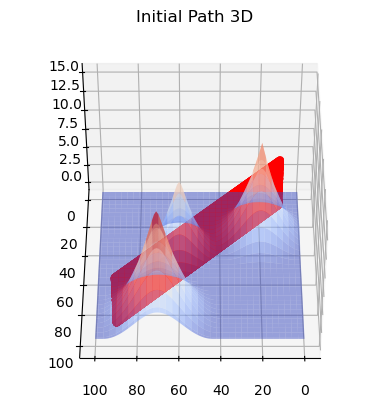

In [312]:
plot_scene(
    initial_path, cost_map, title="Initial Path", save_prefix="../figs/Q6_initial_path"
)

(a) Starting from the straight line path that goes across the obstacle field as in Figure 2, perform gradient descent to find a path with locally optimal cost.
You should represent the path as a sequence of 2D points, view that sequence as a higher-dimensional point in some finite-dimensional space, and take gradient steps in that space.
Rather than optimize along the entire gradient line as we did in lecture, simply scale the negative gradient by 0.1 and take a corresponding step.

Remember, this is a path for your robot, so make sure you don't accidentally optimize its start and goal as well; those should remain fixed.

Plot the path after one iteration — notice that it is moving away from the obstacles.

Pick convergence criteria and plot the path after convergence.
What happened to it?

In [313]:
# Optimization using independent gradient descent
Qa_path_single = initial_path.copy()

optimization_points = Qa_path_single[1:-1]
lr = 0.1
gx, gy = np.gradient(cost_map)

# Create interpolation functions for gradient fields gx and gy
x = np.arange(cost_map.shape[0])
y = np.arange(cost_map.shape[1])

gx_interpolator = interpolate.RegularGridInterpolator(
    (x, y), gx, bounds_error=False, fill_value=None
)
gy_interpolator = interpolate.RegularGridInterpolator(
    (x, y), gy, bounds_error=False, fill_value=None
)

In [314]:
# Perform 1 step of gradient descent
for point in optimization_points:
    # Do bilinear interpolation to get gradient at the precise point
    interpolated_gradient_x = gx_interpolator(point)
    interpolated_gradient_y = gy_interpolator(point)

    # Compute gradient vector
    gradient_vector = np.array(
        [interpolated_gradient_x, interpolated_gradient_y]
    ).flatten()

    # Take a step in the negative gradient direction
    point -= lr * gradient_vector

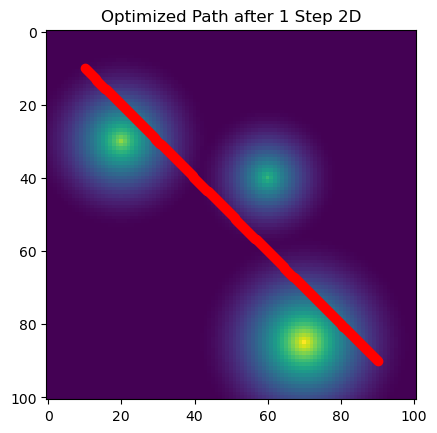

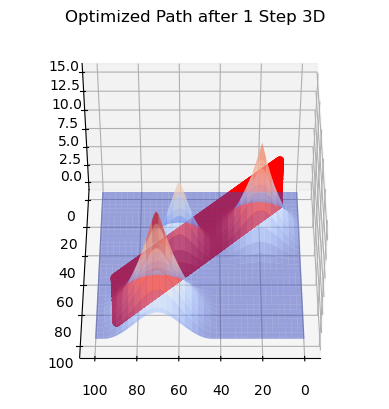

In [315]:
plot_scene(
    Qa_path_single,
    cost_map,
    title="Optimized Path after 1 Step",
    save_prefix="../figs/Q6a_optimized_path_one_step",
)

In [316]:
# Now do continuous optimization with the amount of cost change as criterion
Qa_path_continuous = initial_path.copy()
optimization_points_continuous = Qa_path_continuous[1:-1]
convergence_map = np.zeros(optimization_points_continuous.shape[0], dtype=bool)
cost_interpolator = interpolate.RegularGridInterpolator(
    (x, y), cost_map, bounds_error=False, fill_value=None
)

cost_change_threshold = 1e-3
max_iter = 1000
lr = 0.1

In [317]:
for iter in range(max_iter):
    # if all points have converged, break
    if np.all(convergence_map):
        print(f"Converged after {iter} iterations")
        break

    for idx in range(len(optimization_points_continuous)):
        if convergence_map[idx]:
            continue

        point = optimization_points_continuous[idx]

        # Interpolate gradient at current point
        interpolated_gradient_x = gx_interpolator(point)
        interpolated_gradient_y = gy_interpolator(point)

        # Compute gradient vector
        gradient_vector = np.array(
            [interpolated_gradient_x, interpolated_gradient_y]
        ).flatten()

        current_cost = cost_interpolator(point)

        next_point = point - lr * gradient_vector
        next_cost = cost_interpolator(next_point)

        # Check if the point has converged
        if (current_cost - next_cost) / lr < cost_change_threshold:
            convergence_map[idx] = True

        # Take a step in the negative gradient direction
        optimization_points_continuous[idx] = next_point

Converged after 942 iterations


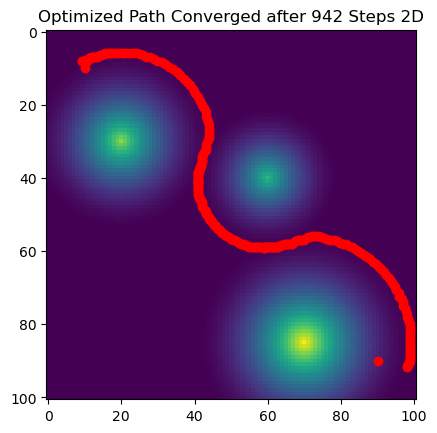

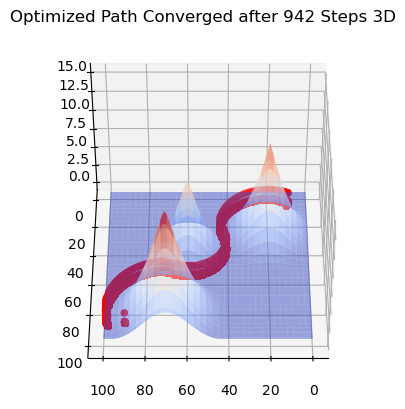

In [318]:
plot_scene(
    Qa_path_continuous,
    cost_map,
    title=f"Optimized Path Converged after {iter} Steps",
    save_prefix="../figs/Q6a_optimized_path_converged",
)

(b) To avoid the issue from part (a), you need to tell the optimizer that this is a path instead of some independent 2D points.

One possibility is to consider an additional cost term, $\min (\frac{1}{2} \|\xi_i - \xi_{i-1}\|^2)$, that tells each 2D point $\xi_i$ to be close to the previous 2D point $\xi_{i-1}$ on the path.
This additional term is sometimes called a *smoothness* cost.

Augment your negative gradient from part (a) with a new negative gradient, obtained for each $\xi_i$ from the *single* term $\frac{1}{2} \|\xi_i - \xi_{i-1}\|^2$.

(The gradient of this new term with respect to $\xi_i$ is $(\xi_i - \xi_{i-1})$.
Include this term for $\xi_i$, but ignore this term when taking a gradient with respect to any other $\xi_j$, including $\xi_{i-1}$.
This means we are really specifying a vector field for the optimizer to follow rather than an overall cost function.
Another perspective is that each 2D point on the path is optimizing its own cost function, chosen in a convenient way.)

Weight the negative obstacle gradient from part (a) with 0.8 and the new negative gradient term with 4, add them together, then again scale that vector by 0.1 and take a corresponding step.
(Weights like this are never set in stone; if you wish, you should feel free to experiment with other values.)

Plot the path after 100, 200 and 500 iterations.
Why doesn't this work?

In [319]:
# Now do gradient descent taking previous path point into account
Qb_path_continuous = initial_path.copy()
optimization_points_continuous = Qb_path_continuous[1:-1]
convergence_map = np.zeros(optimization_points_continuous.shape[0], dtype=bool)
cost_interpolator = interpolate.RegularGridInterpolator(
    (x, y), cost_map, bounds_error=False, fill_value=None
)

cost_change_threshold = 1e-3
max_iter = 5000
lr = 0.1
obstacle_cost_weight = 0.9

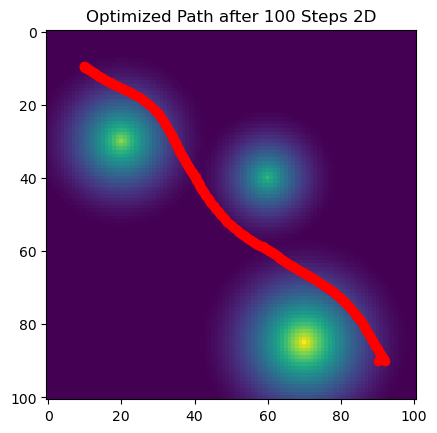

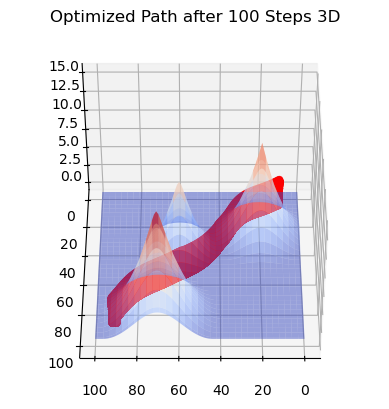

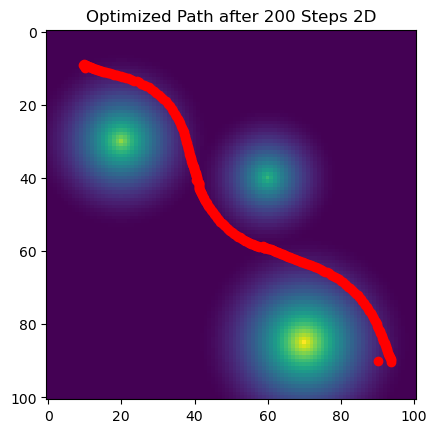

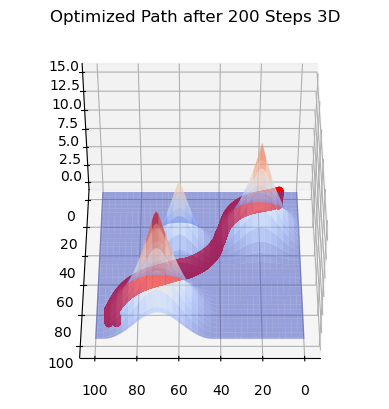

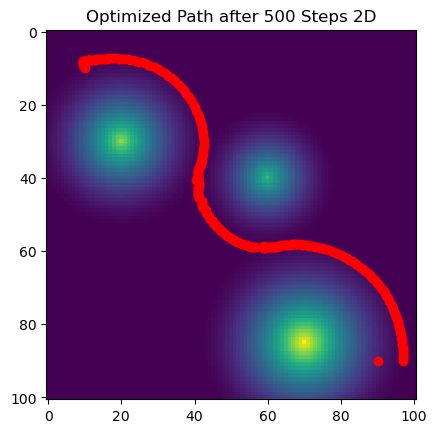

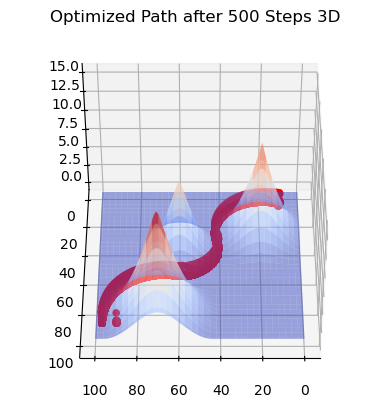

Converged after 1010 iterations


In [320]:
for iter in range(max_iter):
    # if all points have converged, break
    if np.all(convergence_map):
        print(f"Converged after {iter} iterations")
        break

    if iter == 100:
        plot_scene(
            Qb_path_continuous,
            cost_map,
            title="Optimized Path after 100 Steps",
            save_prefix="../figs/Q6b_optimized_path_100_steps",
        )

    if iter == 200:
        plot_scene(
            Qb_path_continuous,
            cost_map,
            title="Optimized Path after 200 Steps",
            save_prefix="../figs/Q6b_optimized_path_200_steps",
        )

    if iter == 500:
        plot_scene(
            Qb_path_continuous,
            cost_map,
            title="Optimized Path after 500 Steps",
            save_prefix="../figs/Q6b_optimized_path_500_steps",
        )

    for idx in range(len(optimization_points_continuous)):
        if convergence_map[idx]:
            continue

        point = optimization_points_continuous[idx]
        previous_path_point = Qb_path_continuous[
            idx
        ]  # using Qb_path_continuous for corner case when idx = 0

        # Interpolate gradient at current point
        interpolated_gradient_x = gx_interpolator(point)
        interpolated_gradient_y = gy_interpolator(point)

        # Compute gradient vector
        gradient_vector = np.array(
            [interpolated_gradient_x, interpolated_gradient_y]
        ).flatten()

        gradient_vector = obstacle_cost_weight * gradient_vector + (
            1 - obstacle_cost_weight
        ) * (point - previous_path_point)

        current_cost = cost_interpolator(point)

        next_point = point - lr * gradient_vector
        next_cost = cost_interpolator(next_point)

        # Check if the point has converged
        if (current_cost - next_cost) / lr < cost_change_threshold:
            convergence_map[idx] = True

        # Take a step in the negative gradient direction
        optimization_points_continuous[idx] = next_point

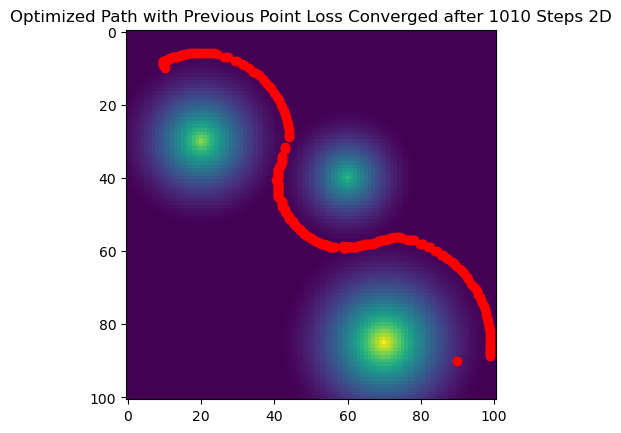

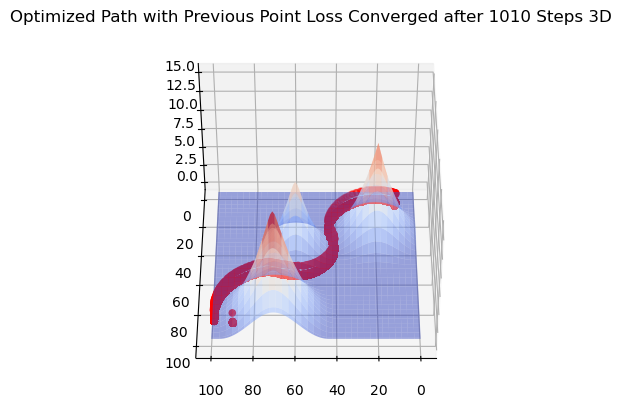

In [321]:
plot_scene(
    Qb_path_continuous,
    cost_map,
    title=f"Optimized Path with Previous Point Loss Converged after {iter} Steps",
    save_prefix="../figs/Q6b_optimized_path_converged",
)

(c) Finally, try augmenting the obstacle gradient with a different smoothness cost, telling each 2D point to be close to both its previous and next points on the path:

$$
        \min (\frac{1}{2} \|\xi_i - \xi_{i-1}\|^2 + \frac{1}{2} \|\xi_i+1 - \xi_i\|^2).
$$

Taking the gradient with respect to $\xi_i$ yields $(\xi_i - \xi_{i-1}) + (\xi_i - \xi_{i+1})$, which is $-\xi_{i-1} + 2\xi_i - \xi_{i+1}$.
(We can now view this gradient as derived from an overall cost function or we can again view it as derived for each 2D point from its own cost function.)
Perform another optimization using this new smoothness cost to compute gradient
updates:

i. Use 0.8 to weight the obstacle cost and 4 to weight the smoothness cost.
Then use a step-size scaling of 0.1 as before.

ii. Again, you should feel free to use different weights if your code works better with those, so long as the weights are not too different from those we suggested.

Plot the path after 100 and 5000 iterations.
Why is this version better?

In [322]:
# Now do gradient descent taking both previous and next path point into account
Qc_path_continuous = initial_path.copy()
optimization_points_continuous = Qc_path_continuous[1:-1]
convergence_map = np.zeros(optimization_points_continuous.shape[0], dtype=bool)
cost_interpolator = interpolate.RegularGridInterpolator(
    (x, y), cost_map, bounds_error=False, fill_value=None
)

cost_change_threshold = 1e-3
max_iter = 5000
lr = 0.1
obstacle_cost_weight = 0.9

converge_iter = 0

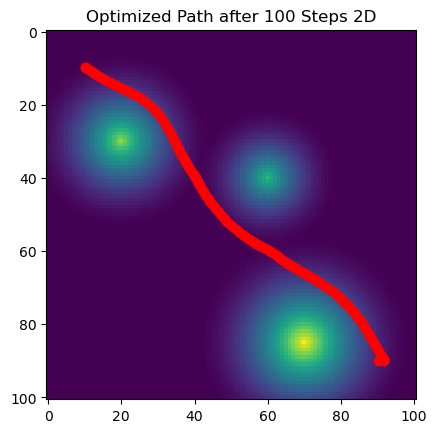

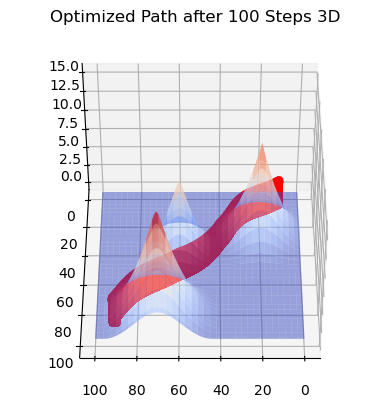

Converged after 1030 iterations


In [323]:
for iter in range(max_iter):
    # if all points have converged, break
    if np.all(convergence_map) and converge_iter == 0:
        print(f"Converged after {iter} iterations")
        converge_iter = iter

    if iter == 100:
        plot_scene(
            Qc_path_continuous,
            cost_map,
            title="Optimized Path after 100 Steps",
            save_prefix="../figs/Q6c_optimized_path_100_steps",
        )

    for idx in range(len(optimization_points_continuous)):
        # if convergence_map[idx]:
        #     continue

        point = optimization_points_continuous[idx]
        previous_path_point = Qc_path_continuous[
            idx
        ]  # using Qc_path_continuous for corner case when idx = 0
        next_path_point = Qc_path_continuous[
            idx + 2
        ]  # using Qc_path_continuous for corner case when idx = the last index

        # Interpolate gradient at current point
        interpolated_gradient_x = gx_interpolator(point)
        interpolated_gradient_y = gy_interpolator(point)

        # Compute gradient vector
        gradient_vector = np.array(
            [interpolated_gradient_x, interpolated_gradient_y]
        ).flatten()

        gradient_vector = obstacle_cost_weight * gradient_vector + (
            1 - obstacle_cost_weight
        ) * (-previous_path_point + 2 * point - next_path_point)

        current_cost = cost_interpolator(point)

        next_point = point - lr * gradient_vector
        next_cost = cost_interpolator(next_point)

        # Check if the point has converged
        if (current_cost - next_cost) / lr < cost_change_threshold:
            convergence_map[idx] = True

        # Take a step in the negative gradient direction
        optimization_points_continuous[idx] = next_point

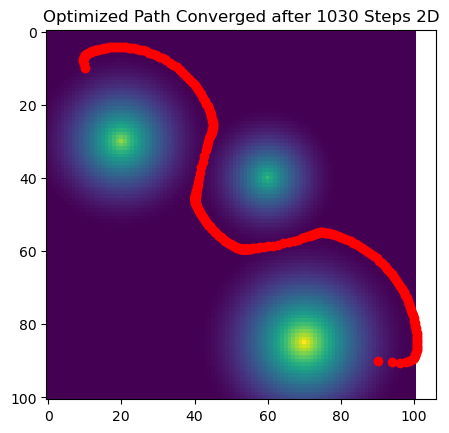

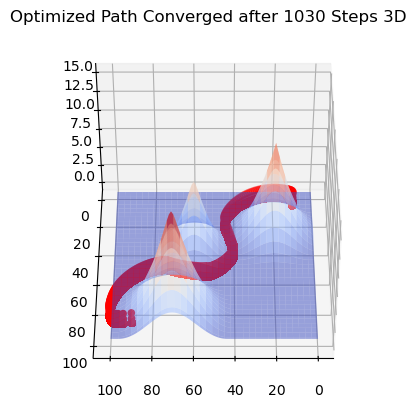

In [324]:
plot_scene(
    Qc_path_continuous,
    cost_map,
    title=f"Optimized Path Converged after {converge_iter} Steps",
    save_prefix="../figs/Q6c_optimized_path_converged",
)

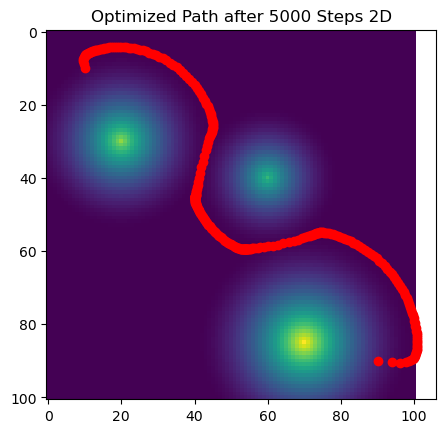

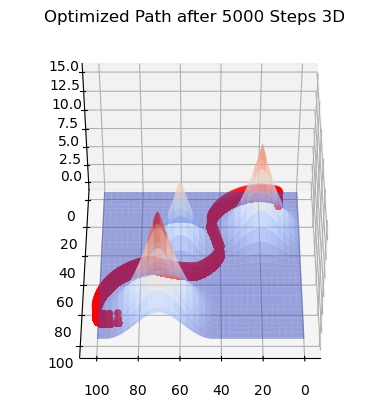

In [325]:
plot_scene(
    Qc_path_continuous,
    cost_map,
    title=f"Optimized Path after {max_iter} Steps",
    save_prefix="../figs/Q6c_optimized_path_max_steps",
)

(d) What will happen if you were to start the procedure from different initial paths?

Will the final answer be the same every time? Why?

(e) Suppose that the final solution path found by gradient descent, given some initial path and given our original cost function, is not feasible for the robot to execute (it still passes through some high cost regions that you would rather not have the robot pass through)?
What simple common-sense strategy can you come up with to try to mitigate this problem?
(\textit{No need to write code unless necessary.
        We expect a very short description of the strategy only.})

Please submit code for parts (a), (b), and (c), but none is required for (d) and (e).
Please provide answers for all parts in your pdf, as usual.
In particular, replicate any code snippets in your pdf that you think the TAs will need for grading.